# Stage 3

In [1]:
# ============================================================
# Stage 3. Load Stage 2 outputs
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_DIR = Path("/Users/ilg/Desktop/year4/M4R/python_files")

OUTPUT_DIR = PROJECT_DIR / "eda_output_unnormalised"

STAGE2_DIR = OUTPUT_DIR / "02_feature_quality_control"

# Prefer the no-missing version if you created it.
FEATURES_NO_MISSING_PATH = STAGE2_DIR / "features_filtered_raw_no_missing.csv"
FEATURES_FILTERED_RAW_PATH = STAGE2_DIR / "features_filtered_raw.csv"
METADATA_STAGE2_PATH = STAGE2_DIR / "metadata_stage2.csv"

STAGE3_DIR = OUTPUT_DIR / "03_sigmoid_normalisation"
STAGE3_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_SIGMOID_PATH = STAGE3_DIR / "features_sigmoid_normalised.csv"
NORMALISATION_PARAMS_PATH = STAGE3_DIR / "sigmoid_normalisation_parameters.csv"
NORMALISATION_QC_PATH = STAGE3_DIR / "sigmoid_normalisation_qc.csv"
METADATA_STAGE3_PATH = STAGE3_DIR / "metadata_stage3.csv"

if FEATURES_NO_MISSING_PATH.exists():
    features_raw = pd.read_csv(FEATURES_NO_MISSING_PATH)
    print(f"Loaded no-missing Stage 2 features: {FEATURES_NO_MISSING_PATH}")
else:
    features_raw = pd.read_csv(FEATURES_FILTERED_RAW_PATH)
    print(f"Loaded Stage 2 features: {FEATURES_FILTERED_RAW_PATH}")

metadata_df = pd.read_csv(METADATA_STAGE2_PATH)

print("metadata shape:", metadata_df.shape)
print("features_raw shape:", features_raw.shape)

Loaded Stage 2 features: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/02_feature_quality_control/features_filtered_raw.csv
metadata shape: (1044, 15)
features_raw shape: (1044, 1214)


In [2]:
# ============================================================
# Stage 3.1 Basic checks before normalisation
# ============================================================

features_raw = features_raw.apply(pd.to_numeric, errors="coerce")
features_raw = features_raw.replace([np.inf, -np.inf], np.nan)

missing_total = features_raw.isna().sum().sum()
inf_total = np.isinf(features_raw.to_numpy(dtype=float)).sum()

print("Total missing values:", missing_total)
print("Total infinite values:", inf_total)

if missing_total > 0:
    print("There are still missing values. They will be median-imputed before sigmoid normalisation.")

Total missing values: 0
Total infinite values: 0


In [3]:
# ============================================================
# Stage 3.2 Median impute any remaining missing values
# ============================================================
# This should only matter if you did not use features_filtered_raw_no_missing.csv.

feature_medians = features_raw.median(axis=0, skipna=True)
features_imputed = features_raw.fillna(feature_medians)

print("Missing values after imputation:", features_imputed.isna().sum().sum())

Missing values after imputation: 0


In [4]:
# ============================================================
# Stage 3.3 Define robust sigmoid normalisation
# ============================================================
# For each feature x:
#
#   z = (x - median(x)) / scale
#   sigmoid = 1 / (1 + exp(-z))
#
# where scale is estimated robustly from the IQR:
#
#   scale = IQR / 1.349
#
# because for a normal distribution, IQR ≈ 1.349 * sigma.
#
# Interpretation:
#   median maps to 0.5
#   large positive values approach 1
#   large negative values approach 0
#   outliers are compressed rather than allowed to dominate PCA

def sigmoid_normalise_feature(x, min_scale=1e-12, clip_z=60):
    x = pd.Series(x).astype(float)

    median = x.median()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr = q3 - q1

    robust_scale = iqr / 1.35

    # Fallback if IQR is zero or numerically tiny.
    if not np.isfinite(robust_scale) or robust_scale < min_scale:
        robust_scale = x.std()

    # Final fallback. This should rarely happen because Stage 2 removed near-constant features.
    if not np.isfinite(robust_scale) or robust_scale < min_scale:
        robust_scale = 1.0

    z = (x - median) / robust_scale
    z = np.clip(z, -clip_z, clip_z)

    y = 1.0 / (1.0 + np.exp(-z))

    params = {
        "median": median,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "robust_scale": robust_scale,
        "min_raw": x.min(),
        "max_raw": x.max(),
        "mean_raw": x.mean(),
        "std_raw": x.std(),
        "min_sigmoid": y.min(),
        "max_sigmoid": y.max(),
        "mean_sigmoid": y.mean(),
        "std_sigmoid": y.std(),
    }

    return y, params

In [5]:
# ============================================================
# Stage 3.4 Apply sigmoid normalisation to all features
# ============================================================

normalised_columns = {}
params_rows = []

for col in features_imputed.columns:
    y, params = sigmoid_normalise_feature(features_imputed[col])

    normalised_columns[col] = y
    params["feature"] = col
    params_rows.append(params)

features_sigmoid = pd.DataFrame(normalised_columns)
normalisation_params = pd.DataFrame(params_rows)

print("Sigmoid-normalised feature matrix shape:", features_sigmoid.shape)
print("Min value in normalised matrix:", features_sigmoid.min().min())
print("Max value in normalised matrix:", features_sigmoid.max().max())
print("Missing values:", features_sigmoid.isna().sum().sum())
print("Infinite values:", np.isinf(features_sigmoid.to_numpy(dtype=float)).sum())

Sigmoid-normalised feature matrix shape: (1044, 1214)
Min value in normalised matrix: 3.4431491012678013e-13
Max value in normalised matrix: 1.0
Missing values: 0
Infinite values: 0


In [6]:
# ============================================================
# Stage 3.5 Normalisation QC
# ============================================================

normalisation_qc = normalisation_params.copy()

normalisation_qc["raw_range"] = (
    normalisation_qc["max_raw"] - normalisation_qc["min_raw"]
)

normalisation_qc["sigmoid_range"] = (
    normalisation_qc["max_sigmoid"] - normalisation_qc["min_sigmoid"]
)

normalisation_qc["compressed_near_zero"] = normalisation_qc["min_sigmoid"] < 0.01
normalisation_qc["compressed_near_one"] = normalisation_qc["max_sigmoid"] > 0.99

print("Features with values compressed near 0:")
print(int(normalisation_qc["compressed_near_zero"].sum()))

print("Features with values compressed near 1:")
print(int(normalisation_qc["compressed_near_one"].sum()))

display(
    normalisation_qc.sort_values("raw_range", ascending=False)
    [["feature", "min_raw", "median", "max_raw", "iqr", "robust_scale", "min_sigmoid", "max_sigmoid"]]
    .head(20)
)

Features with values compressed near 0:
291
Features with values compressed near 1:
910


,feature,min_raw,median,max_raw,iqr,robust_scale,min_sigmoid,max_sigmoid
645,pyspoc.statistics.basic.SpearmanR.feature_spea...,2.149062e+04,1.268038e+07,2.008927e+86,2.964603e+14,2.196002e+14,0.500000,1.000000
432,pyspoc.statistics.basic.KendallTau.feature_ken...,7.252837e+01,1.745381e+03,1.283576e+47,1.969808e+07,1.459117e+07,0.499971,1.000000
216,pyspoc.statistics.basic.Precision.feature_prec...,1.158802e-06,6.868472e-02,4.190426e+10,2.414250e+01,1.788333e+01,0.499040,1.000000
0,pyspoc.statistics.basic.Covariance.feature_cov...,2.386392e-11,1.455981e+01,8.629604e+05,8.149263e+02,6.036491e+02,0.493970,1.000000
859,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,1.026709e+04,2.089684e+04,1.380946e+05,2.239254e+04,1.658706e+04,0.345055,0.999147
865,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,1.026709e+04,2.055731e+04,1.380946e+05,1.858131e+04,1.376393e+04,0.321340,0.999804
862,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,1.026709e+04,2.093939e+04,1.380874e+05,2.056764e+04,1.523529e+04,0.331702,0.999542
160,pyspoc.statistics.basic.Covariance.feature_cov...,5.339604e-03,1.100952e-02,3.345488e+02,1.202002e-02,8.903721e-03,0.345970,1.000000
207,pyspoc.statistics.basic.Covariance.feature_cov...,9.865463e+01,1.115838e+02,4.256654e+02,3.951440e+01,2.926993e+01,0.391331,0.999978
123,pyspoc.statistics.basic.Covariance.feature_cov...,5.135024e-03,1.139192e-02,3.036037e+02,1.682157e-02,1.246042e-02,0.377037,1.000000


In [7]:
# ============================================================
# Stage 3.6 Save Stage 3 outputs
# ============================================================

features_sigmoid.to_csv(FEATURES_SIGMOID_PATH, index=False)
normalisation_params.to_csv(NORMALISATION_PARAMS_PATH, index=False)
normalisation_qc.to_csv(NORMALISATION_QC_PATH, index=False)
metadata_df.to_csv(METADATA_STAGE3_PATH, index=False)

print(f"Sigmoid-normalised features saved to: {FEATURES_SIGMOID_PATH}")
print(f"Normalisation parameters saved to: {NORMALISATION_PARAMS_PATH}")
print(f"Normalisation QC saved to: {NORMALISATION_QC_PATH}")
print(f"Metadata saved to: {METADATA_STAGE3_PATH}")

Sigmoid-normalised features saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/03_sigmoid_normalisation/features_sigmoid_normalised.csv
Normalisation parameters saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/03_sigmoid_normalisation/sigmoid_normalisation_parameters.csv
Normalisation QC saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/03_sigmoid_normalisation/sigmoid_normalisation_qc.csv
Metadata saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/03_sigmoid_normalisation/metadata_stage3.csv


In [8]:
# ============================================================
# Stage 3.7 Quick preview
# ============================================================

display(features_sigmoid.iloc[:5, :10])
display(normalisation_params.head())

,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Determinant.scaled_matrix_determinant,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Diag.matrix_diagonal_entries_1,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Diag.matrix_diagonal_entries_2,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.EigenValues.matrix_eigenvalues_all_1,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.EigenValues.matrix_eigenvalues_all_2,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Moment.columnwise_moments_2_4_1,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Moment.columnwise_moments_2_4_2,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Moment.columnwise_moments_2_4_3,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Moment.columnwise_moments_2_4_4,pyspoc.statistics.basic.Covariance.feature_covariance_matrix.pyspoc.reducers.basic.Moment.columnwise_moments_2_4_5
0,1.0,0.316519,0.385279,0.412494,0.409802,0.414850,0.429487,0.461194,0.470182,0.463986
1,1.0,0.281169,0.526080,0.413233,0.409936,0.399352,0.507289,0.485161,0.435850,0.511724
2,1.0,0.616743,0.414174,0.413373,0.410080,0.539683,0.455528,0.423816,0.446662,0.467991
3,1.0,0.517369,0.564413,0.413506,0.409921,0.497703,0.529026,0.461694,0.486125,0.446237
4,1.0,0.490011,0.441748,0.413137,0.410271,0.485711,0.471918,0.483205,0.522884,0.521920


,median,q1,q3,iqr,robust_scale,min_raw,max_raw,mean_raw,std_raw,min_sigmoid,max_sigmoid,mean_sigmoid,std_sigmoid,feature
0,14.559809,0.041549,814.967844,814.926295,603.649107,2.386392e-11,862960.422402,6554.202230,38468.346034,0.493970,1.0,0.634122,0.204517,pyspoc.statistics.basic.Covariance.feature_cov...
1,1.030267,0.982250,1.174808,0.192558,0.142635,8.940858e-01,10.195631,1.309297,0.831713,0.277930,1.0,0.578755,0.231927,pyspoc.statistics.basic.Covariance.feature_cov...
2,1.025078,0.979163,1.157933,0.178771,0.132423,9.204675e-01,9.742403,1.303091,0.803770,0.312174,1.0,0.591763,0.223145,pyspoc.statistics.basic.Covariance.feature_cov...
3,6.948123,2.931296,23.066052,20.134756,14.914634,1.665369e+00,225.840371,18.029591,29.263261,0.412364,1.0,0.583905,0.192538,pyspoc.statistics.basic.Covariance.feature_cov...
4,5.024400,2.354643,14.776044,12.421401,9.201038,1.618522e+00,164.413872,12.595349,19.770196,0.408502,1.0,0.587361,0.200786,pyspoc.statistics.basic.Covariance.feature_cov...


# stage 4

In [9]:
# ============================================================
# Stage 4. Load Stage 3 outputs
# ============================================================
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

PROJECT_DIR = Path("/Users/ilg/Desktop/year4/M4R/python_files")

OUTPUT_DIR = PROJECT_DIR / "eda_output_unnormalised"

STAGE3_DIR = OUTPUT_DIR / "03_sigmoid_normalisation"

FEATURES_SIGMOID_PATH = STAGE3_DIR / "features_sigmoid_normalised.csv"
METADATA_STAGE3_PATH = STAGE3_DIR / "metadata_stage3.csv"

STAGE4_DIR = OUTPUT_DIR / "04_pca"
STAGE4_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_DIR = STAGE4_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PCA_SCORES_PATH = STAGE4_DIR / "pca_scores.csv"
PCA_LOADINGS_PATH = STAGE4_DIR / "pca_loadings.csv"
PCA_EXPLAINED_VARIANCE_PATH = STAGE4_DIR / "pca_explained_variance.csv"
TOP_LOADINGS_PATH = STAGE4_DIR / "top_loadings_pc1_pc2_pc3.csv"

features = pd.read_csv(FEATURES_SIGMOID_PATH)
metadata = pd.read_csv(METADATA_STAGE3_PATH)

print("features shape:", features.shape)
print("metadata shape:", metadata.shape)

assert len(features) == len(metadata), "features and metadata have different row counts"

features shape: (1044, 1214)
metadata shape: (1044, 15)


In [10]:
# ============================================================
# Stage 4.1 Final checks before PCA
# ============================================================

features = features.apply(pd.to_numeric, errors="coerce")

missing_total = features.isna().sum().sum()
inf_total = np.isinf(features.to_numpy(dtype=float)).sum()

print("Missing values:", missing_total)
print("Infinite values:", inf_total)

if missing_total > 0:
    raise ValueError("There are still missing values. Fix Stage 3 before PCA.")

if inf_total > 0:
    raise ValueError("There are still infinite values. Fix Stage 3 before PCA.")

X = features.to_numpy(dtype=float)

print("PCA input matrix shape:", X.shape)
print("Min:", X.min())
print("Max:", X.max())

Missing values: 0
Infinite values: 0
PCA input matrix shape: (1044, 1214)
Min: 3.4431491012678013e-13
Max: 1.0


In [11]:
# ============================================================
# Stage 4.2 Run PCA
# ============================================================

# 50 components is enough for the main EDA plots and cumulative variance curve.
# You can increase this later if needed.
n_components = min(50, X.shape[0], X.shape[1])

pca = PCA(n_components=n_components)
scores = pca.fit_transform(X)

pc_names = [f"PC{i+1}" for i in range(n_components)]

pca_scores = pd.DataFrame(scores, columns=pc_names)
pca_scores_with_metadata = pd.concat([metadata.reset_index(drop=True), pca_scores], axis=1)

loadings = pd.DataFrame(
    pca.components_.T,
    index=features.columns,
    columns=pc_names
)

explained_variance = pd.DataFrame({
    "PC": pc_names,
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    "singular_value": pca.singular_values_,
})

print("PCA scores shape:", pca_scores.shape)
print("PCA loadings shape:", loadings.shape)

display(explained_variance.head(10))

PCA scores shape: (1044, 50)
PCA loadings shape: (1214, 50)


,PC,explained_variance_ratio,cumulative_explained_variance,singular_value
0,PC1,0.165506,0.165506,102.618103
1,PC2,0.065752,0.231258,64.680230
2,PC3,0.017497,0.248756,33.365796
3,PC4,0.014595,0.263351,30.473706
4,PC5,0.012867,0.276218,28.612235
5,PC6,0.012127,0.288345,27.777973
6,PC7,0.011694,0.300039,27.276969
7,PC8,0.011613,0.311652,27.182581
8,PC9,0.010908,0.322560,26.344242
9,PC10,0.010181,0.332741,25.451210


In [12]:
# ============================================================
# Stage 4.3 Save PCA outputs
# ============================================================

pca_scores_with_metadata.to_csv(PCA_SCORES_PATH, index=False)
loadings.to_csv(PCA_LOADINGS_PATH)
explained_variance.to_csv(PCA_EXPLAINED_VARIANCE_PATH, index=False)

print(f"PCA scores saved to: {PCA_SCORES_PATH}")
print(f"PCA loadings saved to: {PCA_LOADINGS_PATH}")
print(f"Explained variance saved to: {PCA_EXPLAINED_VARIANCE_PATH}")

PCA scores saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/pca_scores.csv
PCA loadings saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/pca_loadings.csv
Explained variance saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/pca_explained_variance.csv


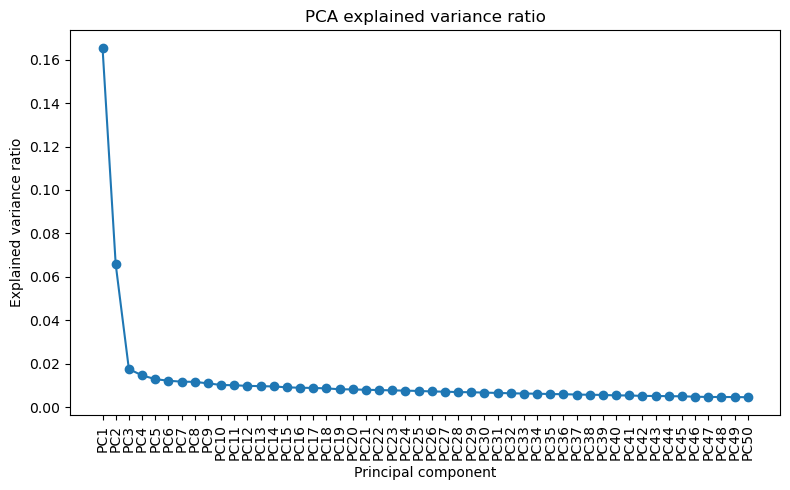

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_explained_variance_ratio.png


In [13]:
# ============================================================
# Stage 4.4 Plot explained variance
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(
    explained_variance["PC"],
    explained_variance["explained_variance_ratio"],
    marker="o"
)
plt.xticks(rotation=90)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("PCA explained variance ratio")
plt.tight_layout()

plot_path = PLOTS_DIR / "pca_explained_variance_ratio.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print(f"Saved plot to: {plot_path}")

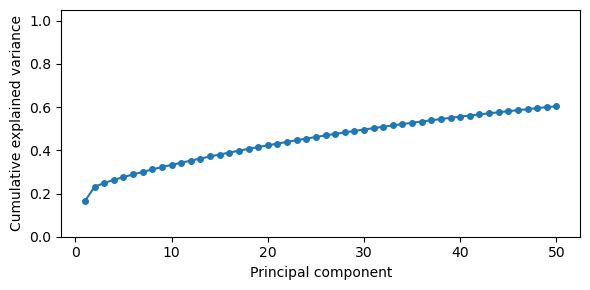

In [ ]:
# # ============================================================
# # Stage 4.5 Plot cumulative explained variance
# # ============================================================

plt.figure(figsize=(6, 3))

x_components = range(1, len(explained_variance) + 1)

plt.plot(
    x_components,
    explained_variance["cumulative_explained_variance"],
    marker="o",
    markersize=4
)

plt.xlabel("Principal component")
plt.ylabel("Cumulative explained variance")
plt.ylim(0, 1.05)
plt.tight_layout()


plt.show()


In [15]:
# ============================================================
# Stage 4.6 PCA scatter plot helpers
# ============================================================

def plot_pca_numeric_colour(scores_df, colour_col, output_name):
    plt.figure(figsize=(7, 6))

    scatter = plt.scatter(
        scores_df["PC1"],
        scores_df["PC2"],
        c=scores_df[colour_col],
        alpha=0.8,
        s=30
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA scores coloured by {colour_col}")
    plt.colorbar(scatter, label=colour_col)
    plt.tight_layout()

    plot_path = PLOTS_DIR / output_name
    plt.savefig(plot_path, dpi=300)
    plt.show()

    print(f"Saved plot to: {plot_path}")


def plot_pca_categorical_colour(scores_df, colour_col, output_name):
    plt.figure(figsize=(7, 6))

    categories = scores_df[colour_col].astype("category")
    codes = categories.cat.codes

    scatter = plt.scatter(
        scores_df["PC1"],
        scores_df["PC2"],
        c=codes,
        alpha=0.8,
        s=30
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA scores coloured by {colour_col}")

    handles = []
    labels = []

    for code, category in enumerate(categories.cat.categories):
        handles.append(
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                label=str(category),
                markerfacecolor=scatter.cmap(scatter.norm(code)),
                markeredgecolor="none",
                markersize=7,
            )
        )
        labels.append(str(category))

    plt.legend(handles, labels, title=colour_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()

    plot_path = PLOTS_DIR / output_name
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")

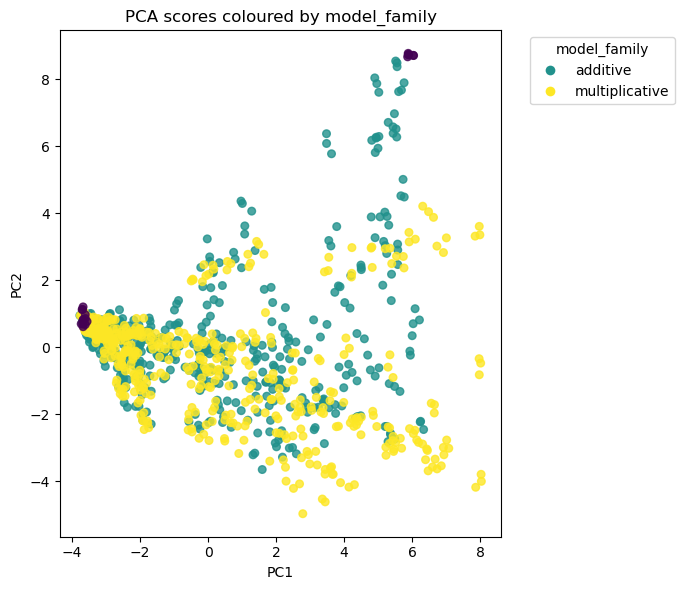

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_model_family.png


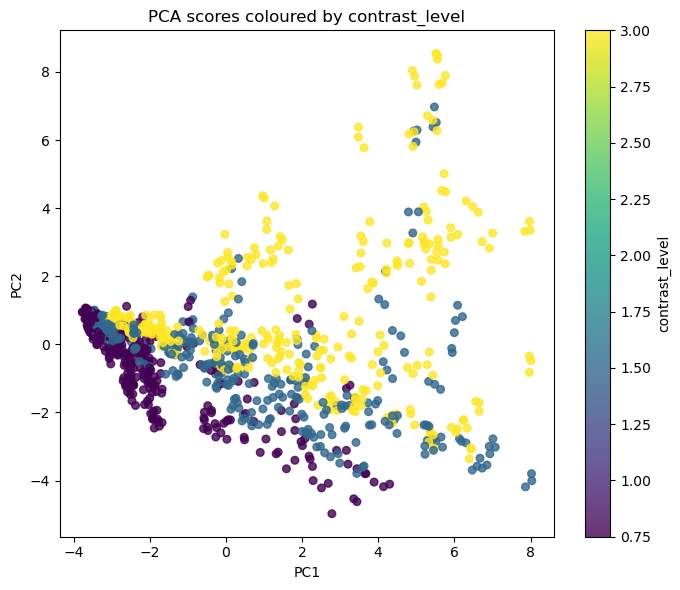

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_contrast_level.png


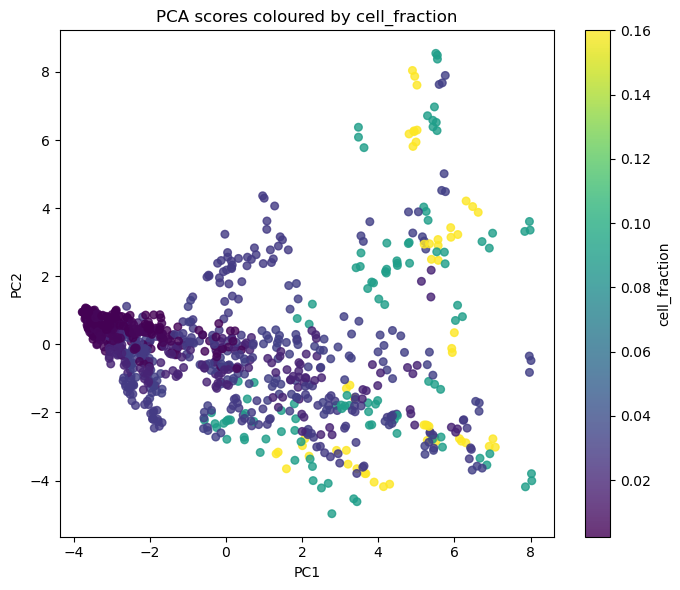

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_cell_fraction.png


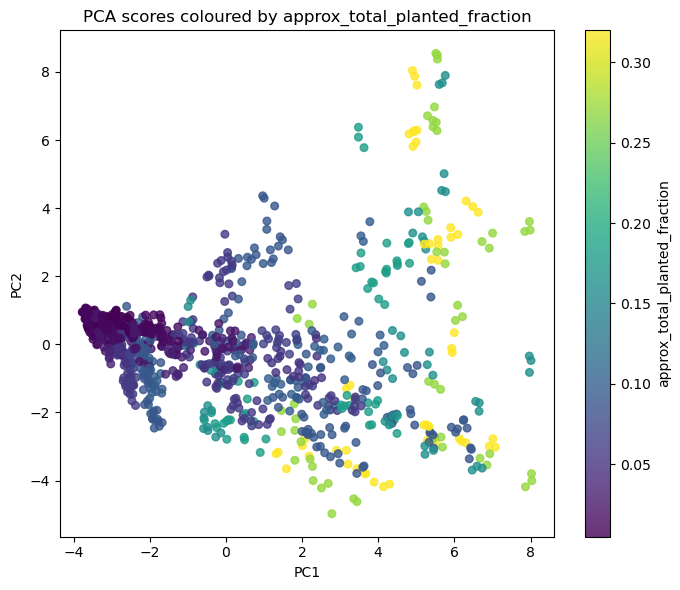

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_total_planted_fraction.png


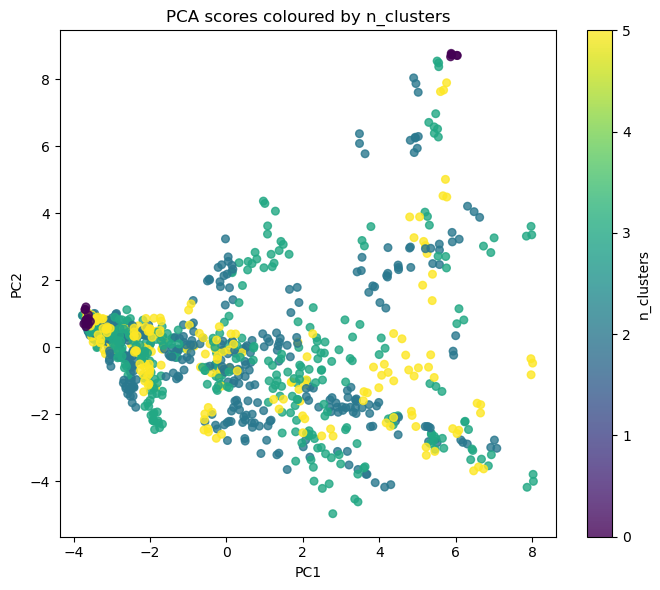

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_true_k.png


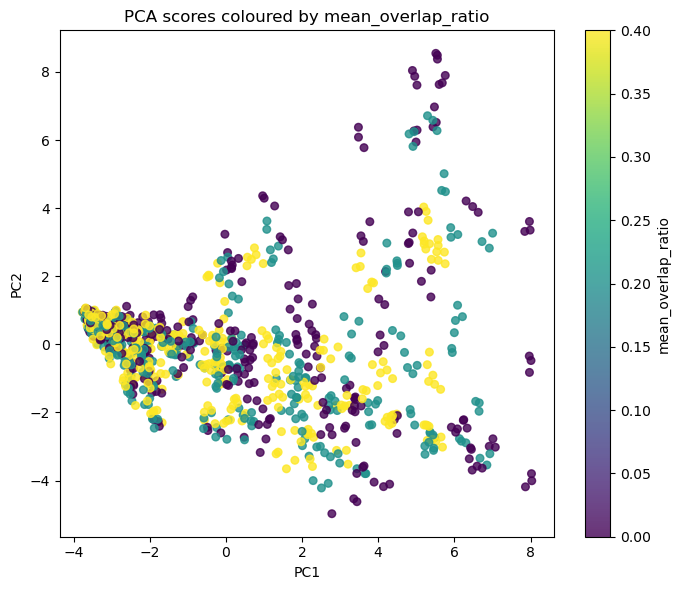

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_mean_overlap_ratio.png


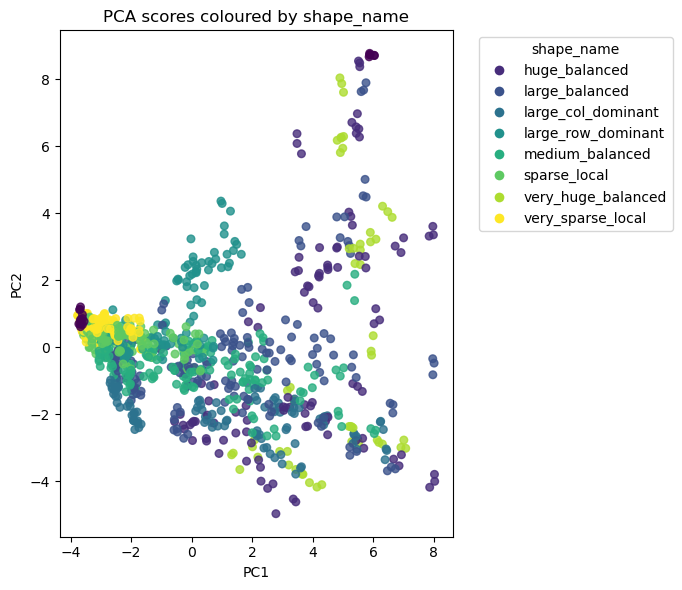

Saved plot to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/plots/pca_pc1_pc2_by_shape_name.png


In [16]:
# ============================================================
# Stage 4.7 Main PCA plots by synthetic design variables
# ============================================================

if "model_family" in pca_scores_with_metadata.columns:
    plot_pca_categorical_colour(
        pca_scores_with_metadata,
        "model_family",
        "pca_pc1_pc2_by_model_family.png"
    )

if "contrast_level" in pca_scores_with_metadata.columns:
    plot_pca_numeric_colour(
        pca_scores_with_metadata,
        "contrast_level",
        "pca_pc1_pc2_by_contrast_level.png"
    )

if "cell_fraction" in pca_scores_with_metadata.columns:
    plot_pca_numeric_colour(
        pca_scores_with_metadata,
        "cell_fraction",
        "pca_pc1_pc2_by_cell_fraction.png"
    )

if "approx_total_planted_fraction" in pca_scores_with_metadata.columns:
    plot_pca_numeric_colour(
        pca_scores_with_metadata,
        "approx_total_planted_fraction",
        "pca_pc1_pc2_by_total_planted_fraction.png"
    )

if "n_clusters" in pca_scores_with_metadata.columns:
    plot_pca_numeric_colour(
        pca_scores_with_metadata,
        "n_clusters",
        "pca_pc1_pc2_by_true_k.png"
    )

if "mean_overlap_ratio" in pca_scores_with_metadata.columns:
    plot_pca_numeric_colour(
        pca_scores_with_metadata,
        "mean_overlap_ratio",
        "pca_pc1_pc2_by_mean_overlap_ratio.png"
    )

if "shape_name" in pca_scores_with_metadata.columns:
    plot_pca_categorical_colour(
        pca_scores_with_metadata,
        "shape_name",
        "pca_pc1_pc2_by_shape_name.png"
    )

In [17]:
# ============================================================
# Stage 4.8 Extract top loading features for PC1, PC2, PC3
# ============================================================

def get_top_loadings(loadings_df, pc, top_n=20):
    pc_loadings = loadings_df[pc].sort_values()

    bottom = pc_loadings.head(top_n).reset_index()
    bottom.columns = ["feature", "loading"]
    bottom["PC"] = pc
    bottom["direction"] = "negative"

    top = pc_loadings.tail(top_n).sort_values(ascending=False).reset_index()
    top.columns = ["feature", "loading"]
    top["PC"] = pc
    top["direction"] = "positive"

    return pd.concat([top, bottom], ignore_index=True)


top_loadings_list = []

for pc in ["PC1", "PC2", "PC3"]:
    if pc in loadings.columns:
        top_loadings_list.append(get_top_loadings(loadings, pc, top_n=20))

top_loadings = pd.concat(top_loadings_list, ignore_index=True)
top_loadings.to_csv(TOP_LOADINGS_PATH, index=False)

display(top_loadings)

print(f"Top loadings saved to: {TOP_LOADINGS_PATH}")

,feature,loading,PC,direction
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.060873,PC1,positive
1,pyspoc.statistics.basic.Covariance.feature_cov...,0.060537,PC1,positive
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.058761,PC1,positive
3,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058629,PC1,positive
4,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449,PC1,positive
...,...,...,...,...
115,pyspoc.rstatistics.pca.PCAVarianceExplainedRat...,-0.058505,PC3,negative
116,pyspoc.statistics.basic.Covariance.feature_cov...,-0.057593,PC3,negative
117,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.056361,PC3,negative
118,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.054827,PC3,negative


Top loadings saved to: /Users/ilg/Desktop/year4/M4R/python_files/eda_output_unnormalised/04_pca/top_loadings_pc1_pc2_pc3.csv


In [18]:
# ============================================================
# Stage 4.9 Quick interpretation table
# ============================================================

for pc in ["PC1", "PC2", "PC3"]:
    if pc not in loadings.columns:
        continue

    print("=" * 80)
    print(pc)
    print("Explained variance ratio:",
          explained_variance.loc[explained_variance["PC"] == pc, "explained_variance_ratio"].iloc[0])

    print("\nTop positive loadings:")
    display(
        top_loadings[
            (top_loadings["PC"] == pc) &
            (top_loadings["direction"] == "positive")
        ][["feature", "loading"]].head(10)
    )

    print("\nTop negative loadings:")
    display(
        top_loadings[
            (top_loadings["PC"] == pc) &
            (top_loadings["direction"] == "negative")
        ][["feature", "loading"]].head(10)
    )

PC1
Explained variance ratio: 0.1655062440807273

Top positive loadings:


,feature,loading
0,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.060873
1,pyspoc.statistics.basic.Covariance.feature_cov...,0.060537
2,/Users/ilg/Desktop/year4/M4R/python_files/Plai...,0.058761
3,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058629
4,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449
5,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058449
6,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058308
7,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.058275
8,pyspoc.statistics.basic.KendallTau.feature_ken...,0.058233
9,pyspoc.statistics.basic.SpearmanR.feature_spea...,0.058162



Top negative loadings:


,feature,loading
20,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.058315
21,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.057412
22,pyspoc.statistics.basic.Precision.feature_prec...,-0.054811
23,pyspoc.statistics.basic.Covariance.feature_cov...,-0.050319
24,pyspoc.statistics.basic.Precision.feature_prec...,-0.047400
25,pyspoc.statistics.basic.Covariance.feature_cov...,-0.043650
26,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.036700
27,pyspoc.statistics.basic.Precision.feature_prec...,-0.035679
28,pyspoc.statistics.basic.Precision.feature_prec...,-0.035679
29,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.034470


PC2
Explained variance ratio: 0.06575208477856326

Top positive loadings:


...

,feature,loading
60,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.029022
61,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.027192
62,pyspoc.statistics.basic.Covariance.feature_cov...,-0.026346
63,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.025981
64,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.025244
65,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.025236
66,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.023970
67,/Users/ilg/Desktop/year4/M4R/python_files/summ...,-0.023729
68,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.023660
69,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,-0.023503


PC3
Explained variance ratio: 0.01749723402041881

Top positive loadings:


,feature,loading
80,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.110755
81,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.084457
82,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,0.079091
83,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.078798
84,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.076388
85,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.075401
86,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,0.070444
87,/Users/ilg/Desktop/year4/M4R/python_files/summ...,0.068200
88,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,0.067862
89,pyspoc.rstatistics.pca.PCAEigenVectors.pca_eig...,0.067000



Top negative loadings:


,feature,loading
100,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.088572
101,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.087919
102,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.076058
103,pyspoc.statistics.basic.Covariance.feature_cov...,-0.072173
104,pyspoc.statistics.basic.Covariance.feature_cov...,-0.071488
105,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.063170
106,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.062826
107,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.062397
108,pyspoc.statistics.basic.KendallTau.feature_ken...,-0.061936
109,pyspoc.statistics.basic.SpearmanR.feature_spea...,-0.061766
